<a href="https://colab.research.google.com/github/SimonCreater/Detect_Object_Through_satellite_image/blob/main/buildingDetectionwithUnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow==2.11.0 # Install a compatible TensorFlow version

In [ ]:
import glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image

from tensorflow import keras
from tensorflow.python.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate, Dropout
from tensorflow.keras.models import load_model
from sklearn.model_selection import KFold
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model

In [ ]:
# connect google drive
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
import os
os.chdir(r'/content/gdrive/MyDrive/archive (2)')

In [ ]:

train_x = sorted(glob.glob('train/*_image.tif'))
train_y = sorted(glob.glob('train/*_label.tif'))
test_x = sorted(glob.glob('test/*_image.tif'))
test_y = sorted(glob.glob('test/*_label.tif'))

print(len(train_x), len(test_x))

70 30


In [ ]:
!pip install scikit-learn

In [ ]:
train_xx = np.zeros((70, 128, 128, 3))
train_yy = np.zeros((70, 128, 128, 1))
for i, (img, mask) in enumerate(zip(train_x, train_y)):
  # if i == 1:
  #   break

  img = Image.open(img)
  np_img = np.array(img)
  train_xx[i] = np_img

  mask = Image.open(mask)
  np_mask = np.array(mask).reshape(128, 128, 1)
  train_yy[i] = np_mask

In [ ]:
test_xx = np.zeros((30, 128, 128, 3))
test_yy = np.zeros((30, 128, 128, 1))
for i, (img, mask) in enumerate(zip(test_x, test_y)):

  img = Image.open(img)
  np_img = np.array(img)
  test_xx[i] = np_img

  mask = Image.open(mask)
  np_mask = np.array(mask).reshape(128, 128, 1)
  test_yy[i] = np_mask

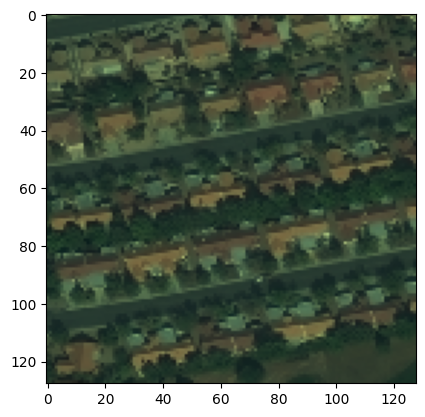

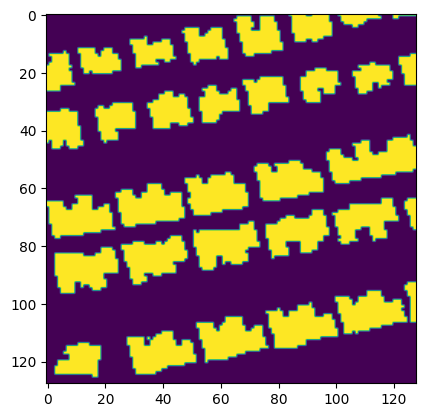

In [ ]:
plt.imshow(train_xx[20, :, :, :].astype('uint8'))
plt.show()
plt.imshow(train_yy[20, :, :, 0].astype('uint8'))
plt.show()

In [ ]:
np.save('train_xx.npy', train_xx)
np.save('train_yy.npy', train_yy)
np.save("test_xx.npy", test_xx)
np.save("test_yy.npy", test_yy)

In [ ]:
x_in = Input(shape=(128, 128, 3))

'''Encoder'''
x_temp = Conv2D(32, (3, 3), activation='relu', padding='same')(x_in)
x_temp = Dropout(0.25)(x_temp)
x_skip1 = Conv2D(32, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = MaxPooling2D((2,2))(x_skip1)
x_temp = Conv2D(32, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = Dropout(0.25)(x_temp)
x_skip2 = Conv2D(32, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = MaxPooling2D((2,2))(x_skip2)
x_temp = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = Dropout(0.25)(x_temp)
x_skip3 = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = MaxPooling2D((2,2))(x_skip3)
x_temp = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)
x_temp = Dropout(0.5)(x_temp)
x_temp = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)

'''Decoder'''
x_temp = Conv2DTranspose(64, (3, 3), activation='relu',  padding='same')(x_temp)
x_temp = Dropout(0.5)(x_temp)
x_temp = Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu',  padding='same')(x_temp)
x_temp = Concatenate()([x_temp, x_skip3])
x_temp = Conv2DTranspose(64, (3, 3), activation='relu',  padding='same')(x_temp)
x_temp = Dropout(0.5)(x_temp)
x_temp = Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu',  padding='same')(x_temp)
x_temp = Concatenate()([x_temp, x_skip2])
x_temp = Conv2DTranspose(32, (3, 3), activation='relu',  padding='same')(x_temp)
x_temp = Dropout(0.5)(x_temp)
x_temp = Conv2DTranspose(32, (3, 3), strides=(2, 2), activation='relu',  padding='same')(x_temp)
x_temp = Concatenate()([x_temp, x_skip1])
x_temp = Conv2DTranspose(32, (3, 3), activation='relu',  padding='same')(x_temp)
x_temp = Dropout(0.5)(x_temp)
x_temp = Conv2DTranspose(32, (3, 3), activation='relu',  padding='same')(x_temp)

'''Use 1 by 1 Convolution to get desired output bands'''
x_temp = Conv2D(32, (1, 1), activation='relu', padding='same')(x_temp)
x_temp = Conv2D(32, (1, 1), activation='relu', padding='same')(x_temp)
x_out = Conv2D(1, (1, 1), activation='sigmoid', padding='same')(x_temp)
# use sigmoid activation here because output values are either 0 or 1

model = Model(inputs=x_in, outputs=x_out)

model.compile(loss='mean_squared_error', optimizer='adam')

model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 128, 128, 32  896         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 dropout (Dropout)              (None, 128, 128, 32  0           ['conv2d[0][0]']                 
                                )                                                             

In [ ]:
def create_model():
    x_in = Input(shape=(128, 128, 3))

    # Encoder
    x_temp = Conv2D(32, (3, 3), activation='relu', padding='same')(x_in)
    x_temp = Dropout(0.25)(x_temp)
    x_skip1 = Conv2D(32, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = MaxPooling2D((2, 2))(x_skip1)
    x_temp = Conv2D(32, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = Dropout(0.25)(x_temp)
    x_skip2 = Conv2D(32, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = MaxPooling2D((2, 2))(x_skip2)
    x_temp = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = Dropout(0.25)(x_temp)
    x_skip3 = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = MaxPooling2D((2, 2))(x_skip3)
    x_temp = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = Dropout(0.5)(x_temp)
    x_temp = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)

    # Decoder
    x_temp = Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = Dropout(0.5)(x_temp)
    x_temp = Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu', padding='same')(x_temp)
    x_temp = Concatenate()([x_temp, x_skip3])
    x_temp = Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = Dropout(0.5)(x_temp)
    x_temp = Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu', padding='same')(x_temp)
    x_temp = Concatenate()([x_temp, x_skip2])
    x_temp = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = Dropout(0.5)(x_temp)
    x_temp = Conv2DTranspose(32, (3, 3), strides=(2, 2), activation='relu', padding='same')(x_temp)
    x_temp = Concatenate()([x_temp, x_skip1])
    x_temp = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = Dropout(0.5)(x_temp)
    x_temp = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x_temp)

    # Output
    x_temp = Conv2D(32, (1, 1), activation='relu', padding='same')(x_temp)
    x_temp = Conv2D(32, (1, 1), activation='relu', padding='same')(x_temp)
    x_out = Conv2D(1, (1, 1), activation='sigmoid', padding='same')(x_temp)

    model = Model(inputs=x_in, outputs=x_out)
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

    return model


In [ ]:
history = model.fit(train_xx, train_yy, validation_data=(test_xx, test_yy), epochs=100, batch_size=10, verbose=1)

Epoch 1/100
7/7 [==============================] - 2s 253ms/step - loss: 0.0730 - val_loss: 0.0824
Epoch 2/100
7/7 [==============================] - 2s 263ms/step - loss: 0.0726 - val_loss: 0.0718
Epoch 3/100
7/7 [==============================] - 2s 260ms/step - loss: 0.0693 - val_loss: 0.0735
Epoch 4/100
7/7 [==============================] - 2s 249ms/step - loss: 0.0697 - val_loss: 0.0780
Epoch 5/100
7/7 [==============================] - 2s 249ms/step - loss: 0.0703 - val_loss: 0.0694
Epoch 6/100
7/7 [==============================] - 2s 248ms/step - loss: 0.0690 - val_loss: 0.0702
Epoch 7/100
7/7 [==============================] - 2s 249ms/step - loss: 0.0661 - val_loss: 0.0704
Epoch 8/100
7/7 [==============================] - 2s 249ms/step - loss: 0.0647 - val_loss: 0.0686
Epoch 9/100
7/7 [==============================] - 2s 250ms/step - loss: 0.0641 - val_loss: 0.0661
Epoch 10/100
7/7 [==============================] - 2s 261ms/step - loss: 0.0630 - val_loss: 0.0652
Epoch 11/

In [ ]:
print(train_xx.shape)  # 입력 데이터의 크기
print(train_yy.shape)

(70, 128, 128, 3)
(70, 128, 128, 1)


In [ ]:
model.save('/content/gdrive/MyDrive/my_model.h6')

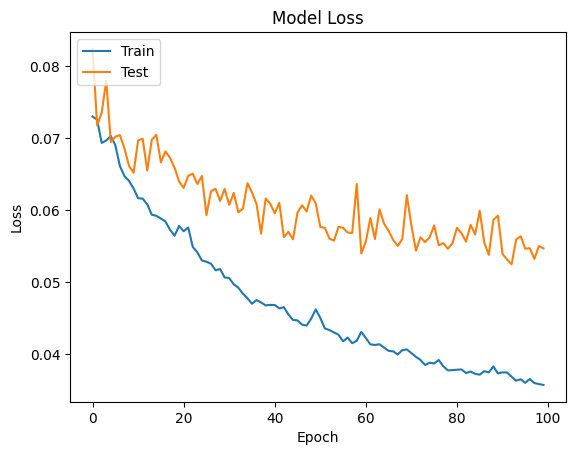

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

1/1 [==============================] - 1s 508ms/step
(30, 128, 128, 1)


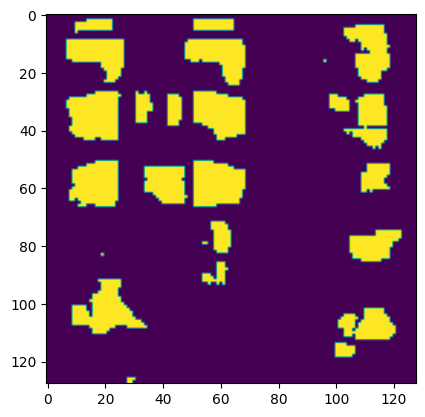

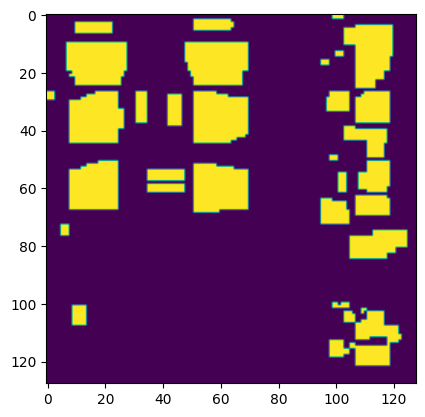

In [ ]:
threshold = 0.5

# prediction of the output
pred_test = model.predict(test_xx)
pred_test = (pred_test > threshold).astype(np.uint8)
print(pred_test.shape)

#let's comare random predicted and actial y values
plt.imshow(pred_test[10, :, :, 0])
plt.show()
plt.imshow(test_yy[10,:,:,0])
plt.show()

In [ ]:
from PIL import Image
import os
def convert_numpy_array_to_img(in_npy, out_folder, channel=3):
    n = in_npy.shape[0]
    for i in range(n):
        if channel==3:
            image = Image.fromarray(in_npy[i].astype('uint8'))
            image.save(os.path.join(out_folder, f"{i}_image.tif"))

        else:
            image = Image.fromarray(in_npy[i, :, :, 0])
            image.save(os.path.join(out_folder, f"{i}_label.tif"))

In [ ]:
# data is already randomized and split in to training / test sets. So we can go ahead and use them as it is.
x_train = np.load('train_xx.npy').astype('float32')
y_train= np.load('train_yy.npy').astype('float32')
x_test = np.load('test_xx.npy').astype('float32')
y_test = np.load('test_yy.npy').astype('float32')

print("x_train shape", x_train.shape)
print("y_train shape", y_train.shape)
print("y_test shape", x_test.shape)
print("y_test shape", y_test.shape)

x_train shape (70, 128, 128, 3)
y_train shape (70, 128, 128, 1)
y_test shape (30, 128, 128, 3)
y_test shape (30, 128, 128, 1)


In [ ]:
convert_numpy_array_to_img(x_train, 'train')
convert_numpy_array_to_img(y_train, 'train', channel=1)

convert_numpy_array_to_img(x_test, 'test')
convert_numpy_array_to_img(y_test, 'test', channel=1)

Training on Fold 1...
Epoch 1/100
8/8 [==============================] - 5s 280ms/step - loss: 0.6932 - accuracy: 0.4997 - val_loss: 0.6932 - val_accuracy: 0.4992
Epoch 2/100
8/8 [==============================] - 2s 235ms/step - loss: 0.6932 - accuracy: 0.5003 - val_loss: 0.6932 - val_accuracy: 0.4993
Epoch 3/100
8/8 [==============================] - 2s 230ms/step - loss: 0.6931 - accuracy: 0.5009 - val_loss: 0.6932 - val_accuracy: 0.4993
Epoch 4/100
8/8 [==============================] - 2s 247ms/step - loss: 0.6931 - accuracy: 0.5008 - val_loss: 0.6932 - val_accuracy: 0.4993
Epoch 5/100
8/8 [==============================] - 2s 244ms/step - loss: 0.6931 - accuracy: 0.5007 - val_loss: 0.6932 - val_accuracy: 0.4993
Epoch 6/100
8/8 [==============================] - 2s 247ms/step - loss: 0.6931 - accuracy: 0.5013 - val_loss: 0.6932 - val_accuracy: 0.4994
Epoch 7/100
8/8 [==============================] - 2s 237ms/step - loss: 0.6931 - accuracy: 0.5009 - val_loss: 0.6932 - val_accuracy

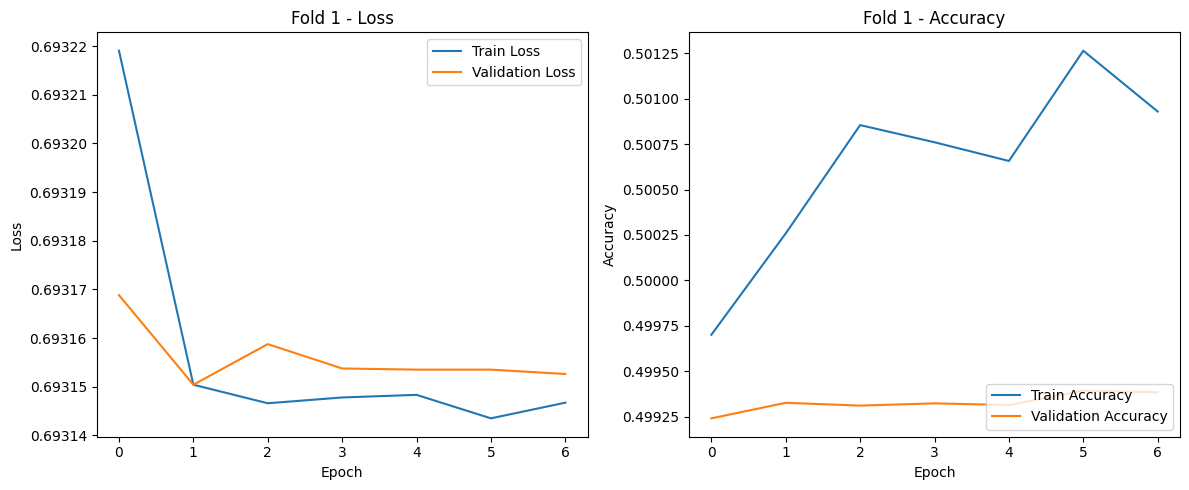

Fold 1 - Accuracy: 0.4994, Loss: 0.6932
Training on Fold 2...
Epoch 1/100
8/8 [==============================] - 5s 282ms/step - loss: 0.6932 - accuracy: 0.4996 - val_loss: 0.6931 - val_accuracy: 0.5022
Epoch 2/100
8/8 [==============================] - 2s 234ms/step - loss: 0.6932 - accuracy: 0.5001 - val_loss: 0.6931 - val_accuracy: 0.5021
Epoch 3/100
8/8 [==============================] - 2s 240ms/step - loss: 0.6932 - accuracy: 0.4991 - val_loss: 0.6931 - val_accuracy: 0.5022
Epoch 4/100
8/8 [==============================] - 2s 247ms/step - loss: 0.6931 - accuracy: 0.4998 - val_loss: 0.6931 - val_accuracy: 0.5019
Epoch 5/100
8/8 [==============================] - 2s 236ms/step - loss: 0.6931 - accuracy: 0.5001 - val_loss: 0.6931 - val_accuracy: 0.5018
Epoch 6/100
8/8 [==============================] - 2s 236ms/step - loss: 0.6931 - accuracy: 0.4997 - val_loss: 0.6931 - val_accuracy: 0.5022


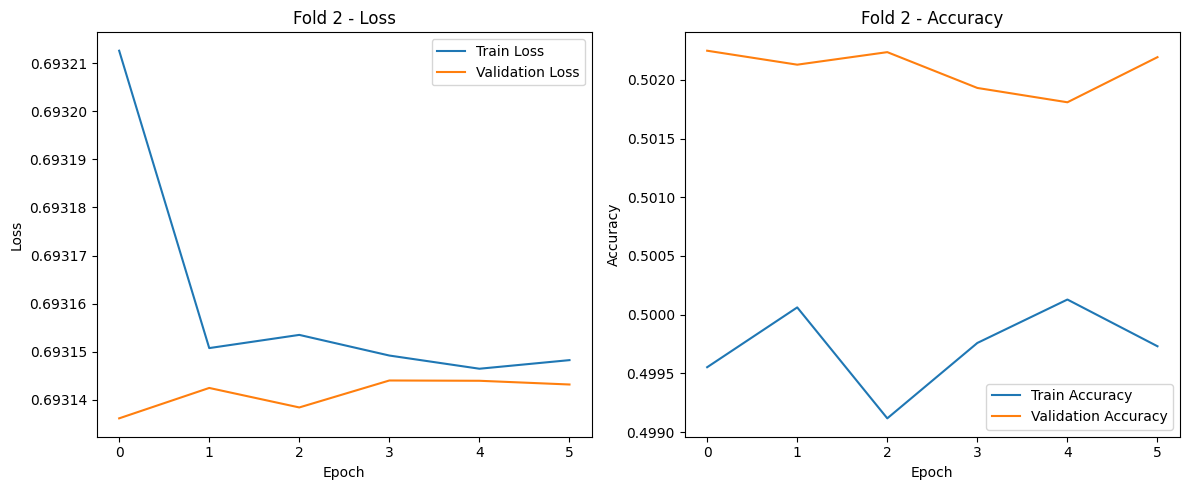

Fold 2 - Accuracy: 0.5022, Loss: 0.6931
Training on Fold 3...
Epoch 1/100
8/8 [==============================] - 6s 279ms/step - loss: 0.6932 - accuracy: 0.5003 - val_loss: 0.6932 - val_accuracy: 0.4998
Epoch 2/100
8/8 [==============================] - 2s 246ms/step - loss: 0.6931 - accuracy: 0.5012 - val_loss: 0.6932 - val_accuracy: 0.4994
Epoch 3/100
8/8 [==============================] - 2s 251ms/step - loss: 0.6932 - accuracy: 0.5004 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 4/100
8/8 [==============================] - 2s 233ms/step - loss: 0.6932 - accuracy: 0.5007 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 5/100
8/8 [==============================] - 2s 233ms/step - loss: 0.6931 - accuracy: 0.5006 - val_loss: 0.6931 - val_accuracy: 0.4999
Epoch 6/100
8/8 [==============================] - 2s 231ms/step - loss: 0.6931 - accuracy: 0.5006 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 7/100
8/8 [==============================] - 2s 233ms/step - loss: 0.6931 - accuracy: 

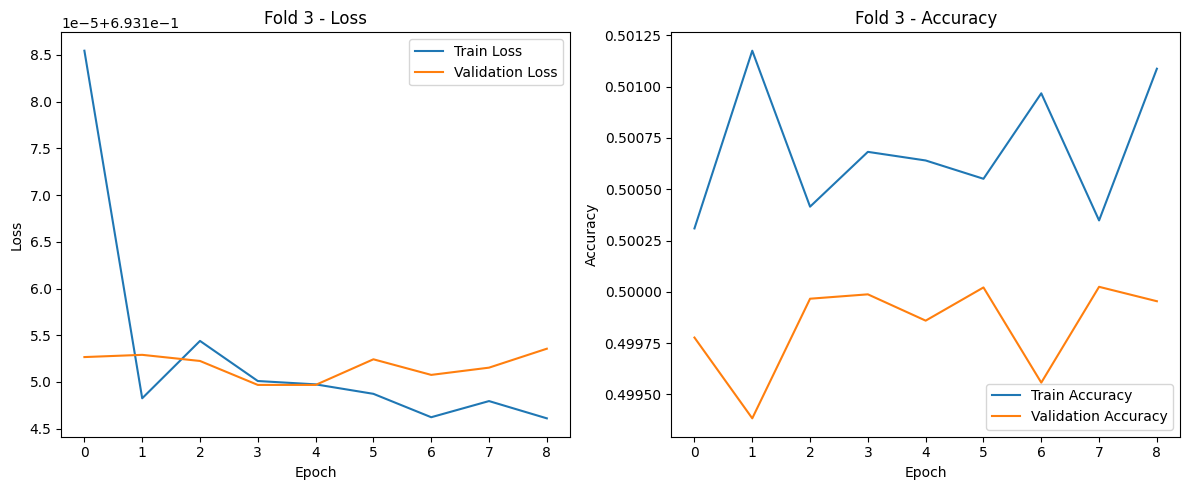

Fold 3 - Accuracy: 0.5000, Loss: 0.6931
Training on Fold 4...
Epoch 1/100
8/8 [==============================] - 5s 278ms/step - loss: 0.6934 - accuracy: 0.5008 - val_loss: 0.6931 - val_accuracy: 0.5015
Epoch 2/100
8/8 [==============================] - 2s 234ms/step - loss: 0.6932 - accuracy: 0.5004 - val_loss: 0.6931 - val_accuracy: 0.5009
Epoch 3/100
8/8 [==============================] - 2s 234ms/step - loss: 0.6932 - accuracy: 0.4999 - val_loss: 0.6931 - val_accuracy: 0.5008
Epoch 4/100
8/8 [==============================] - 2s 231ms/step - loss: 0.6932 - accuracy: 0.4999 - val_loss: 0.6931 - val_accuracy: 0.5015
Epoch 5/100
8/8 [==============================] - 2s 246ms/step - loss: 0.6931 - accuracy: 0.5004 - val_loss: 0.6931 - val_accuracy: 0.5016
Epoch 6/100
8/8 [==============================] - 2s 245ms/step - loss: 0.6931 - accuracy: 0.5007 - val_loss: 0.6931 - val_accuracy: 0.5013
Epoch 7/100
8/8 [==============================] - 2s 233ms/step - loss: 0.6931 - accuracy: 

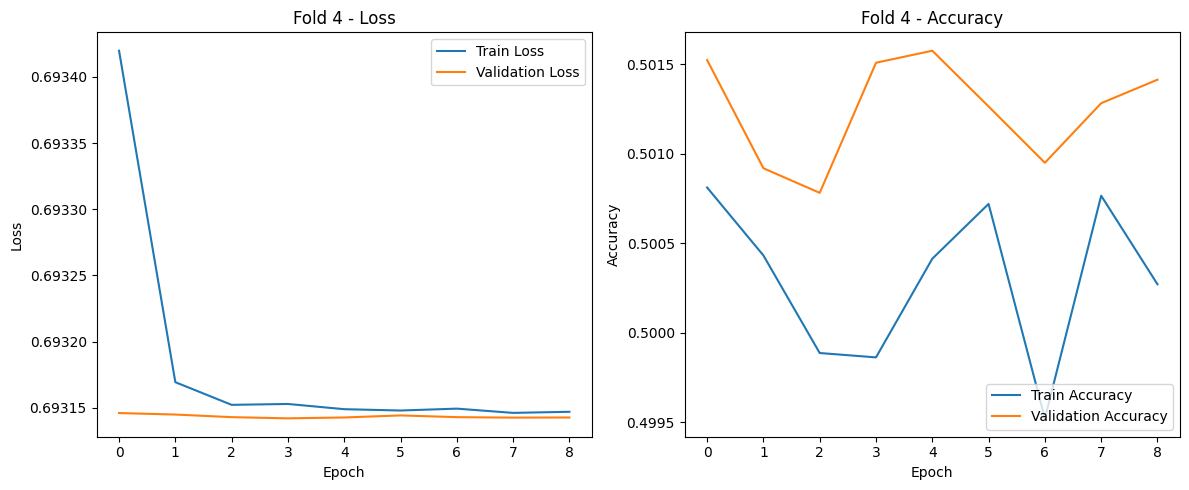

Fold 4 - Accuracy: 0.5016, Loss: 0.6931
Training on Fold 5...
Epoch 1/100
8/8 [==============================] - 5s 291ms/step - loss: 0.6937 - accuracy: 0.5004 - val_loss: 0.6932 - val_accuracy: 0.4995
Epoch 2/100
8/8 [==============================] - 2s 245ms/step - loss: 0.6932 - accuracy: 0.4998 - val_loss: 0.6932 - val_accuracy: 0.4993
Epoch 3/100
8/8 [==============================] - 2s 235ms/step - loss: 0.6932 - accuracy: 0.4994 - val_loss: 0.6932 - val_accuracy: 0.4995
Epoch 4/100
8/8 [==============================] - 2s 234ms/step - loss: 0.6932 - accuracy: 0.4998 - val_loss: 0.6932 - val_accuracy: 0.4996
Epoch 5/100
8/8 [==============================] - 2s 237ms/step - loss: 0.6931 - accuracy: 0.5003 - val_loss: 0.6931 - val_accuracy: 0.5010
Epoch 6/100
8/8 [==============================] - 2s 236ms/step - loss: 0.6931 - accuracy: 0.5005 - val_loss: 0.6931 - val_accuracy: 0.5019
Epoch 7/100
8/8 [==============================] - 2s 233ms/step - loss: 0.6931 - accuracy: 

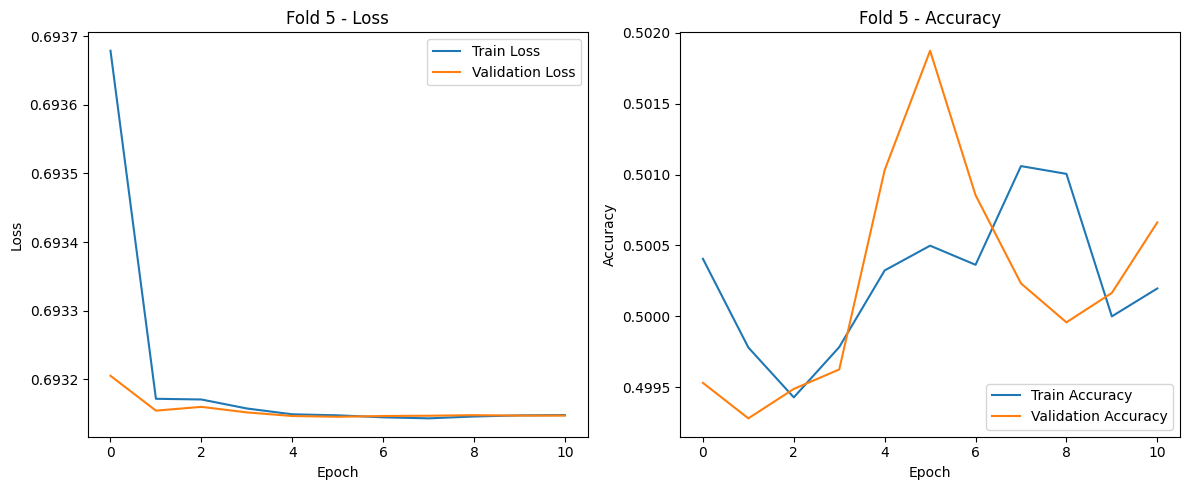

Fold 5 - Accuracy: 0.5019, Loss: 0.6931
Fold Accuracies: [0.49939268827438354, 0.5022491216659546, 0.5000244379043579, 0.501574695110321, 0.501873791217804]
Fold Losses: [0.6931504011154175, 0.6931361556053162, 0.6931496858596802, 0.6931421160697937, 0.6931454539299011]
Mean Validation Accuracy: 0.5010229468345642
Mean Validation Loss: 0.6931447625160218


In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Conv2DTranspose, MaxPooling2D, Dropout, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 교차검증 준비
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-폴드 교차검증

# 교차검증 결과 저장
fold_accuracies = []
fold_losses = []

def create_model():
    x_in = Input(shape=(128, 128, 3))

    # Encoder
    x_temp = Conv2D(32, (3, 3), activation='relu', padding='same')(x_in)
    x_temp = Dropout(0.25)(x_temp)
    x_skip1 = Conv2D(32, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = MaxPooling2D((2, 2))(x_skip1)
    x_temp = Conv2D(32, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = Dropout(0.25)(x_temp)
    x_skip2 = Conv2D(32, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = MaxPooling2D((2, 2))(x_skip2)
    x_temp = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = Dropout(0.25)(x_temp)
    x_skip3 = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = MaxPooling2D((2, 2))(x_skip3)
    x_temp = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = Dropout(0.5)(x_temp)
    x_temp = Conv2D(64, (3, 3), activation='relu', padding='same')(x_temp)

    # Decoder
    x_temp = Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = Dropout(0.5)(x_temp)
    x_temp = Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu', padding='same')(x_temp)
    x_temp = Concatenate()([x_temp, x_skip3])
    x_temp = Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = Dropout(0.5)(x_temp)
    x_temp = Conv2DTranspose(64, (3, 3), strides=(2, 2), activation='relu', padding='same')(x_temp)
    x_temp = Concatenate()([x_temp, x_skip2])
    x_temp = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = Dropout(0.5)(x_temp)
    x_temp = Conv2DTranspose(32, (3, 3), strides=(2, 2), activation='relu', padding='same')(x_temp)
    x_temp = Concatenate()([x_temp, x_skip1])
    x_temp = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x_temp)
    x_temp = Dropout(0.5)(x_temp)
    x_temp = Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x_temp)

    # Output
    x_temp = Conv2D(32, (1, 1), activation='relu', padding='same')(x_temp)
    x_temp = Conv2D(32, (1, 1), activation='relu', padding='same')(x_temp)
    x_out = Conv2D(1, (1, 1), activation='sigmoid', padding='same')(x_temp)

    model = Model(inputs=x_in, outputs=x_out)
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

    return model

# 전체 데이터 (예시)
train_xx = np.random.rand(100, 128, 128, 3)  # 100개의 128x128 RGB 이미지
train_yy = np.random.randint(0, 2, (100, 128, 128, 1))  # 마스크 데이터

# 교차검증 실행
fold = 1
for train_index, val_index in kf.split(train_xx):
    print(f"Training on Fold {fold}...")

    # 학습/검증 데이터 분리
    x_train, x_val = train_xx[train_index], train_xx[val_index]
    y_train, y_val = train_yy[train_index], train_yy[val_index]

    # 모델 생성
    model = create_model()

    # 조기 종료 콜백
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # 모델 학습
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=100,
        batch_size=10,
        callbacks=[early_stopping],
        verbose=1
    )

    # 손실 및 정확도 그래프
    plt.figure(figsize=(12, 5))

    # 손실 그래프
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Fold {fold} - Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')

    # 정확도 그래프
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Fold {fold} - Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

    # 폴드별 손실과 정확도 저장
    val_accuracy = max(history.history['val_accuracy'])
    val_loss = min(history.history['val_loss'])
    fold_accuracies.append(val_accuracy)
    fold_losses.append(val_loss)

    print(f"Fold {fold} - Accuracy: {val_accuracy:.4f}, Loss: {val_loss:.4f}")
    fold += 1

# 최종 결과 출력
print("Fold Accuracies:", fold_accuracies)
print("Fold Losses:", fold_losses)
print("Mean Validation Accuracy:", np.mean(fold_accuracies))
print("Mean Validation Loss:", np.mean(fold_losses))


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 128, 128, 32  896         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 dropout (Dropout)              (None, 128, 128, 32  0           ['conv2d[0][0]']                 
                                )                                                             

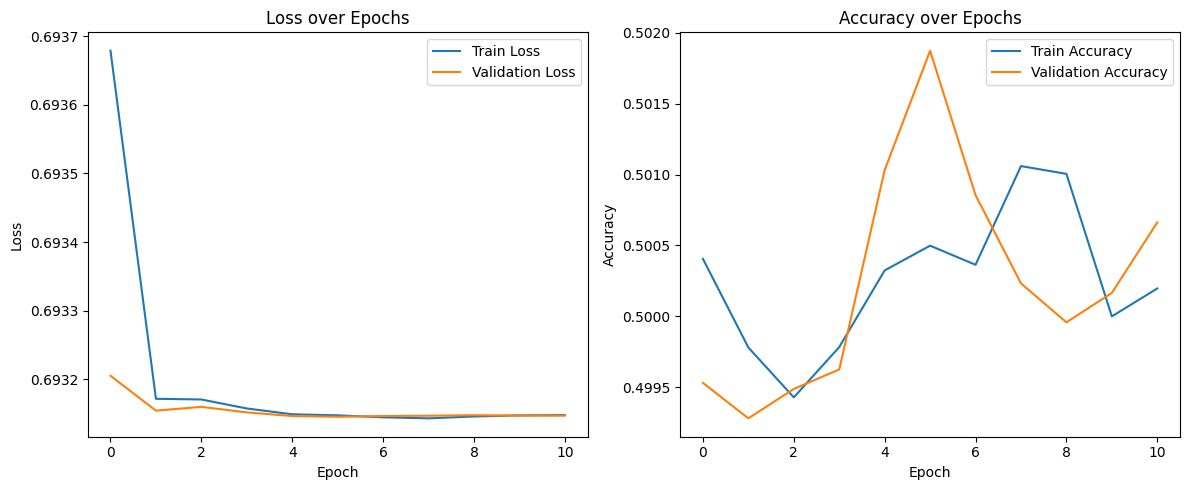

In [ ]:
model = load_model('/content/gdrive/MyDrive/my_model.h6')
model.summary()

plt.figure(figsize=(12, 5))

# 손실 그래프
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 정확도 그래프
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Epoch 1/100
8/8 [==============================] - 5s 287ms/step - loss: 0.3146 - val_loss: 0.2531
Epoch 2/100
8/8 [==============================] - 2s 235ms/step - loss: 0.2518 - val_loss: 0.2501
Epoch 3/100
8/8 [==============================] - 2s 233ms/step - loss: 0.2504 - val_loss: 0.2501
Epoch 4/100
8/8 [==============================] - 2s 233ms/step - loss: 0.2502 - val_loss: 0.2501
Epoch 5/100
8/8 [==============================] - 2s 236ms/step - loss: 0.2501 - val_loss: 0.2501
Epoch 6/100
8/8 [==============================] - 2s 235ms/step - loss: 0.2501 - val_loss: 0.2500
Epoch 7/100
8/8 [==============================] - 2s 240ms/step - loss: 0.2501 - val_loss: 0.2500
Epoch 8/100
8/8 [==============================] - 2s 246ms/step - loss: 0.2500 - val_loss: 0.2500
Epoch 9/100
8/8 [==============================] - 2s 239ms/step - loss: 0.2500 - val_loss: 0.2500
Epoch 10/100
8/8 [==============================] - 2s 233ms/step - loss: 0.2500 - val_loss: 0.2500
Epoch 11/

Epoch 1/10
8/8 [==============================] - 5s 274ms/step - loss: 0.2500 - val_loss: 0.2500
Epoch 2/10
8/8 [==============================] - 2s 232ms/step - loss: 0.2500 - val_loss: 0.2500
Epoch 3/10
8/8 [==============================] - 2s 239ms/step - loss: 0.2500 - val_loss: 0.2500
Epoch 4/10
8/8 [==============================] - 2s 246ms/step - loss: 0.2500 - val_loss: 0.2500
Epoch 5/10
8/8 [==============================] - 2s 239ms/step - loss: 0.2500 - val_loss: 0.2500
Epoch 6/10
8/8 [==============================] - 2s 232ms/step - loss: 0.2500 - val_loss: 0.2500
Epoch 7/10
8/8 [==============================] - 2s 236ms/step - loss: 0.2500 - val_loss: 0.2500
Epoch 8/10
8/8 [==============================] - 2s 234ms/step - loss: 0.2500 - val_loss: 0.2500
Epoch 9/10
8/8 [==============================] - 2s 234ms/step - loss: 0.2500 - val_loss: 0.2500
Epoch 10/10
8/8 [==============================] - 2s 235ms/step - loss: 0.2500 - val_loss: 0.2500


KeyError: 'accuracy'

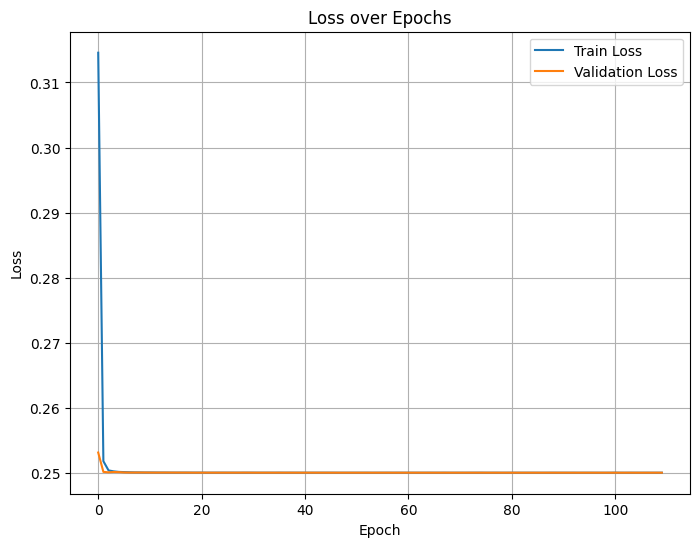

In [ ]:
loss = initial_history.history['loss'] + additional_history.history['loss']
val_loss = initial_history.history['val_loss'] + additional_history.history['val_loss']

# 5. 손실 그래프 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# 손실 그래프
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()